<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

# **SpaceX Falcon 9 First Stage Landing Prediction**

## Assignment: Exploring and Preparing Data

**Author:** Ahmad Waziri

In this notebook we perform exploratory data analysis and feature engineering on the labeled
SpaceX launch dataset, visualizing how flight number, payload mass, launch site, and orbit type
relate to landing success before building the one-hot-encoded feature matrix used for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

First, let's read the SpaceX dataset into a Pandas dataframe and print its summary.

In [1]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df.head(5)

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite      Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount Serial   Longitude   Latitude  Class
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0003  -80.577366  28.561857      0
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0005  -80.577366  28.561857      0
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40    None None        1     False   False  False        NaN    1.0            0  B0007  -80.577366  28.561857      0
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E  False Ocean        1     False   False  False        NaN    1.0            0  B1003 -120.610829  34.632093      0
4             5  2013-12-03       Falcon 9  3

Let's first see how `FlightNumber` (the continuous launch attempt count) and `PayloadMass`
relate to the launch outcome. As the flight number increases, the first stage is more likely to
land successfully -- reflecting SpaceX's growing recovery experience over time.

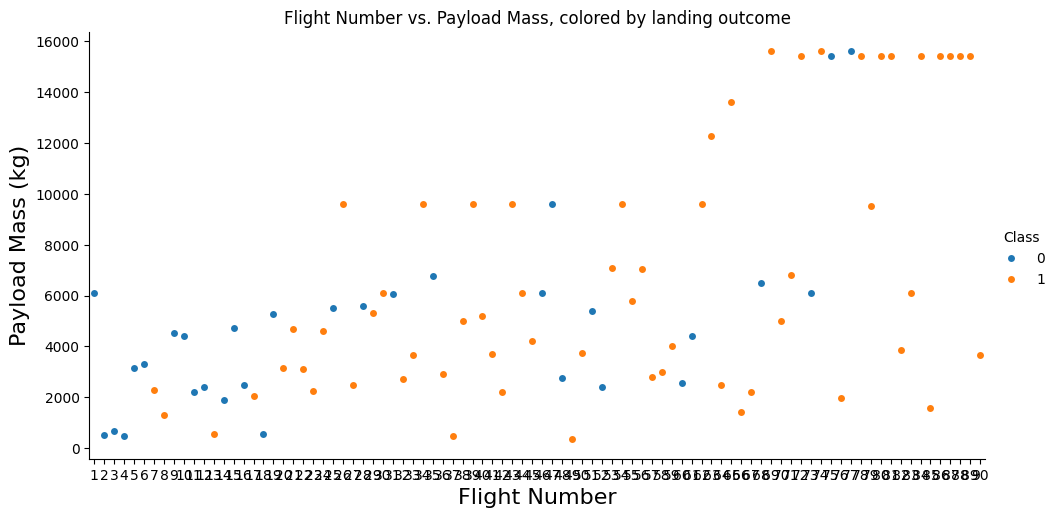

In [1]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=16)
plt.ylabel("Payload Mass (kg)", fontsize=16)
plt.title("Flight Number vs. Payload Mass, colored by landing outcome")
plt.show()

### TASK 1: Visualize the relationship between Flight Number and Launch Site

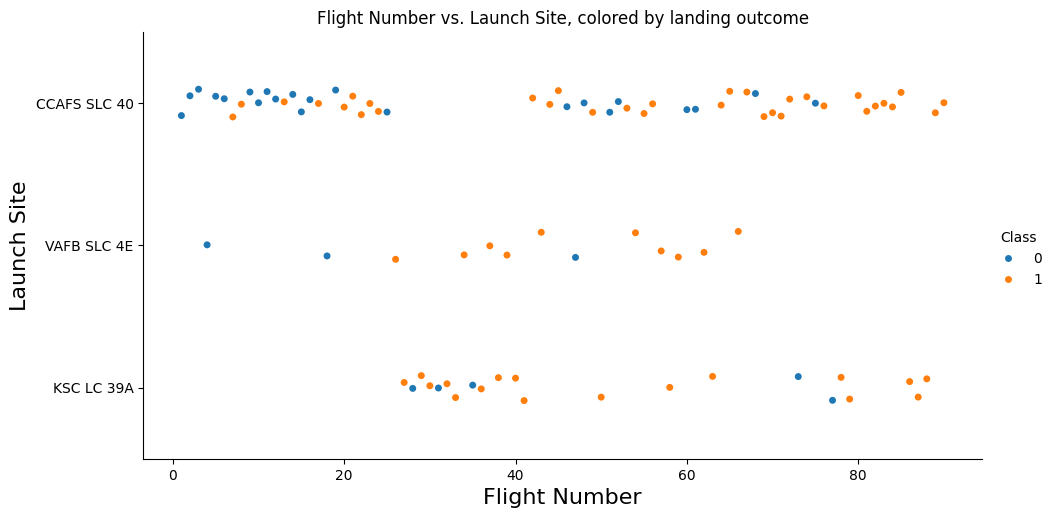

In [1]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=16)
plt.ylabel("Launch Site", fontsize=16)
plt.title("Flight Number vs. Launch Site, colored by landing outcome")
plt.show()

Cape Canaveral SLC-40 hosted the earliest (low flight-number) launches, and its later flights
show a much higher share of successful landings (blue) than its earliest ones -- consistent with
SpaceX's landing technology maturing over the mission timeline.

### TASK 2: Visualize the relationship between Payload Mass and Launch Site

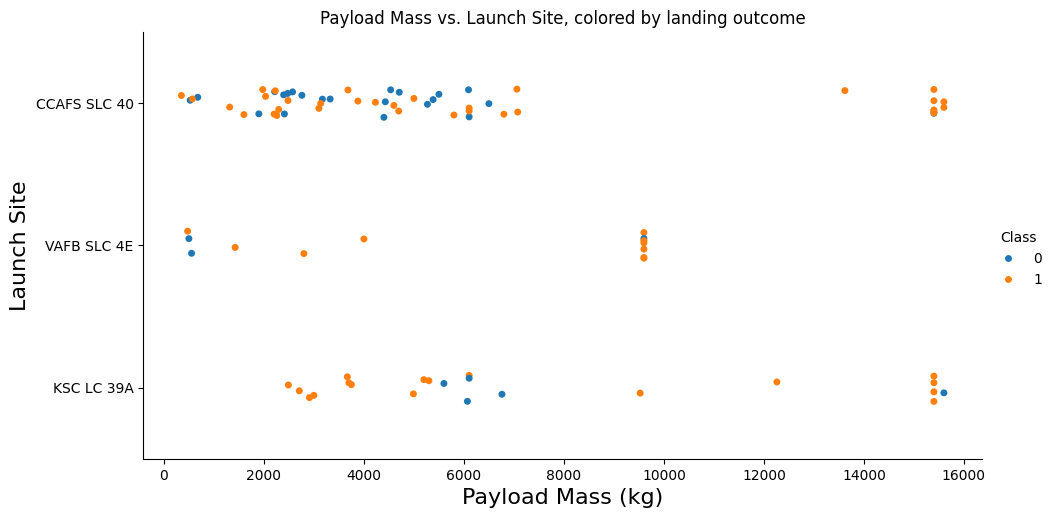

In [1]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=16)
plt.ylabel("Launch Site", fontsize=16)
plt.title("Payload Mass vs. Launch Site, colored by landing outcome")
plt.show()

For the VAFB-SLC launch site, there are no rockets launched with a heavy payload mass (greater than 10,000 kg).

### TASK 3: Visualize the relationship between success rate of each orbit type

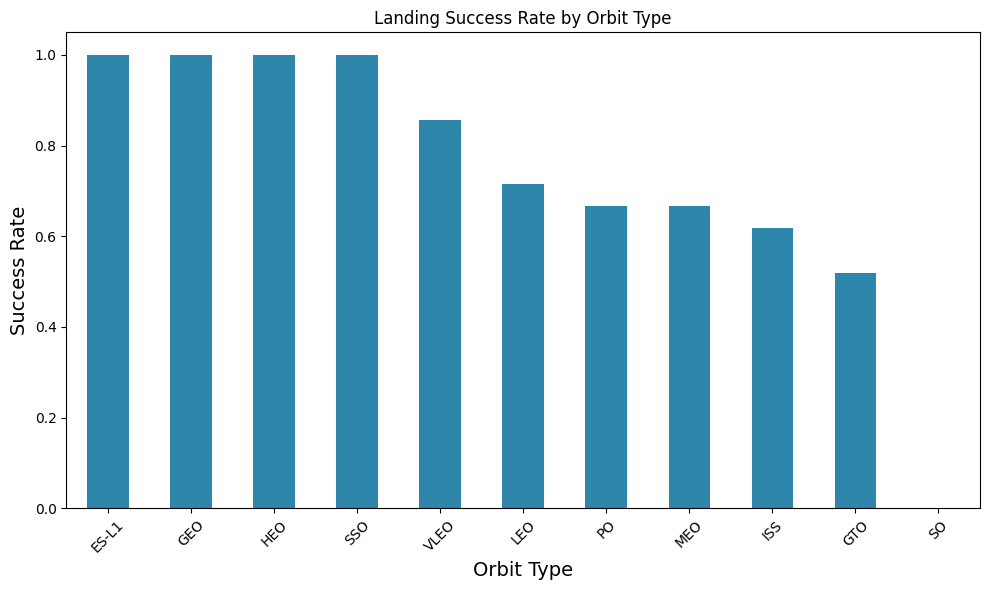

In [1]:
orbit_success = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
orbit_success.plot(kind="bar", color="#2E86AB")
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Landing Success Rate by Orbit Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
orbit_success

Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
PO       0.666667
MEO      0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000

Orbits such as ES-L1, GEO, HEO, and SSO show the highest success rates, while GTO and PO orbits show lower success rates in this dataset.

### TASK 4: Visualize the relationship between FlightNumber and Orbit type

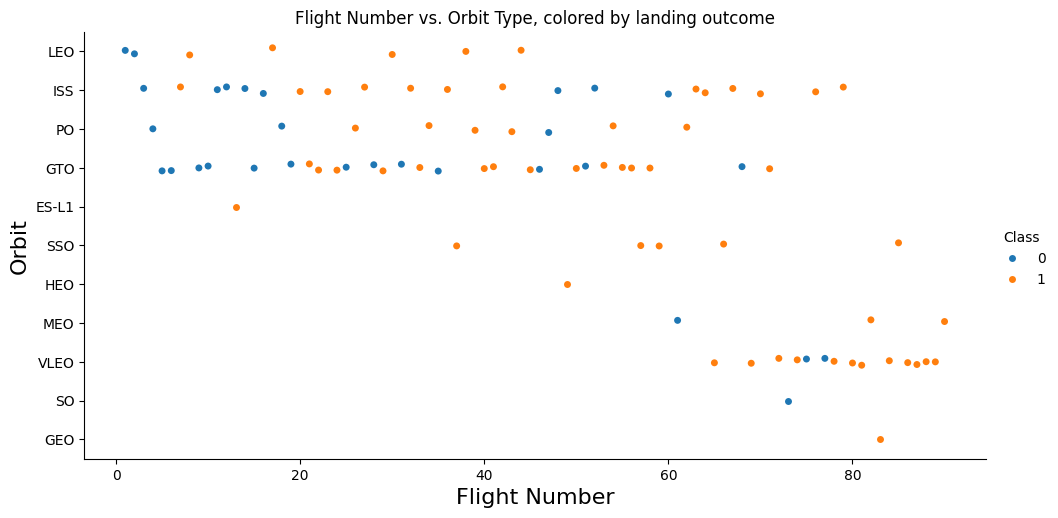

In [1]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=16)
plt.ylabel("Orbit", fontsize=16)
plt.title("Flight Number vs. Orbit Type, colored by landing outcome")
plt.show()

In the LEO orbit, success appears to be related to the number of flights. In GTO, there is no clear relationship between flight number and success.

### TASK 5: Visualize the relationship between Payload Mass and Orbit type

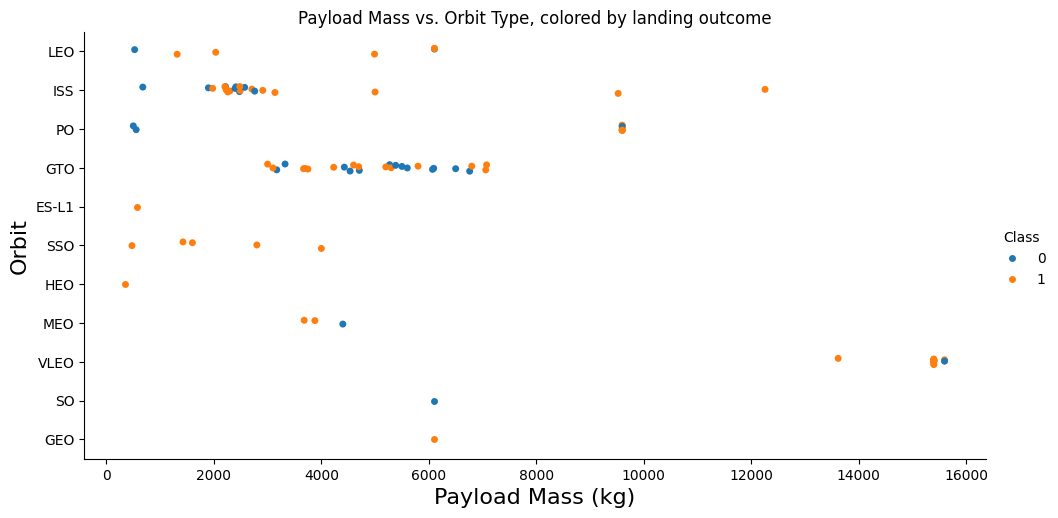

In [1]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=16)
plt.ylabel("Orbit", fontsize=16)
plt.title("Payload Mass vs. Orbit Type, colored by landing outcome")
plt.show()

With heavy payloads, the successful landing rate is higher for Polar, LEO, and ISS orbits.
For GTO, it's difficult to distinguish between successful and unsuccessful landings, since both
outcomes are well represented.

### TASK 6: Visualize the launch success yearly trend

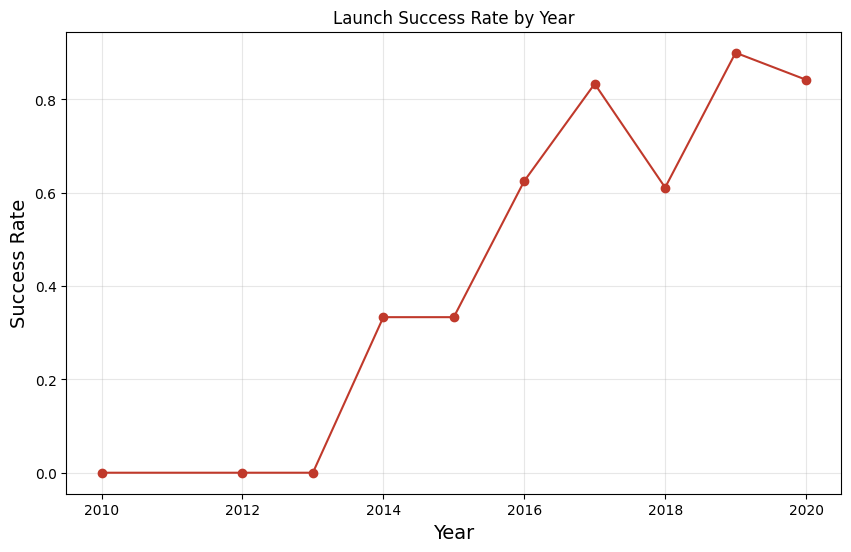

In [1]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
yearly_success.plot(kind='line', marker='o', color="#C0392B")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Launch Success Rate by Year")
plt.grid(alpha=0.3)
plt.show()

In [1]:
yearly_success

Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.333333
2015    0.333333
2016    0.625000
2017    0.833333
2018    0.611111
2019    0.900000
2020    0.842105

The success rate rose substantially from 2013 onward, reflecting SpaceX's steadily improving first-stage recovery technology.

## Feature Engineering

Now we select the features that will be used for success prediction in the next module.

In [1]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
               'ReusedCount', 'Serial']]
features.head()

   FlightNumber  PayloadMass Orbit    LaunchSite  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount Serial
0             1  6104.959412   LEO  CCAFS SLC 40        1     False   False  False        NaN    1.0            0  B0003
1             2   525.000000   LEO  CCAFS SLC 40        1     False   False  False        NaN    1.0            0  B0005
2             3   677.000000   ISS  CCAFS SLC 40        1     False   False  False        NaN    1.0            0  B0007
3             4   500.000000    PO   VAFB SLC 4E        1     False   False  False        NaN    1.0            0  B1003
4             5  3170.000000   GTO  CCAFS SLC 40        1     False   False  False        NaN    1.0            0  B1004

### TASK 7: Create dummy variables for categorical columns

Use `get_dummies()` on the `Orbit`, `LaunchSite`, `LandingPad`, and `Serial` columns. Assign the
result to `features_one_hot`.

In [1]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

   FlightNumber  PayloadMass  Flights  GridFins  Reused   Legs  Block  ReusedCount  Orbit_ES-L1  Orbit_GEO  Orbit_GTO  Orbit_HEO  Orbit_ISS  Orbit_LEO  Orbit_MEO  Orbit_PO  Orbit_SO  Orbit_SSO  Orbit_VLEO  LaunchSite_CCAFS SLC 40  LaunchSite_KSC LC 39A  LaunchSite_VAFB SLC 4E  LandingPad_5e9e3032383ecb267a34e7c7  LandingPad_5e9e3032383ecb554034e7c9  LandingPad_5e9e3032383ecb6bb234e7ca  LandingPad_5e9e3032383ecb761634e7cb  LandingPad_5e9e3033383ecbb9e534e7cc  Serial_B0003  Serial_B0005  Serial_B0007  Serial_B1003  Serial_B1004  Serial_B1005  Serial_B1006  Serial_B1007  Serial_B1008  Serial_B1010  Serial_B1011  Serial_B1012  Serial_B1013  Serial_B1015  Serial_B1016  Serial_B1017  Serial_B1018  Serial_B1019  Serial_B1020  Serial_B1021  Serial_B1022  Serial_B1023  Serial_B1025  Serial_B1026  Serial_B1028  Serial_B1029  Serial_B1030  Serial_B1031  Serial_B1032  Serial_B1034  Serial_B1035  Serial_B1036  Serial_B1037  Serial_B1038  Serial_B1039  Serial_B1040  Serial_B1041  Serial_B1042  Seria

### TASK 8: Cast all numeric columns to `float64`

In [1]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.dtypes.head(10)

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
Legs            float64
Block           float64
ReusedCount     float64
Orbit_ES-L1     float64
Orbit_GEO       float64

In [1]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("Saved dataset_part_3.csv with", features_one_hot.shape[0], "rows and", features_one_hot.shape[1], "columns")

Saved dataset_part_3.csv with 90 rows and 80 columns


## Conclusion

Flight number, payload mass, launch site, and orbit type all show visible relationships with
landing success, and the improvement in success rate over time reflects SpaceX's maturing landing
capability. The one-hot-encoded feature matrix (`dataset_part_3.csv`) is now ready for the
predictive-modeling stage of the pipeline.